# Notebook 01: Data Preprocessing & Feature Engineering

Builds the unified analytical base from both datasets with all PS-required engineered features.

**Assumption log (documented here as required by PS):**
- Revenue is simulated as `tariff × kWhDelivered` against the ₹15/kWh fixed baseline (ACN has no price field).
- UrbanEV ¥/kWh prices are used solely as a price elasticity proxy; the coefficient is treated as an order-of-magnitude estimate, not a calibrated INR elasticity.
- Utilization = Charging Time / Total Available Time (PS definition); for UrbanEV, occupancy / total pile count.
- Missing kWh rows in ACN (~1,305) are dropped (Excel trailing rows with no session data).
- Missing values in UrbanEV lag features arise from the start of each grid's time series; they are left as NaN and handled natively by HistGradientBoosting.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from io_utils import load_acn, load_urbanev_panel
from features import build_acn_features, build_acn_station_hour, build_urbanev_features, BASELINE_TARIFF

OUT_DATA = Path('..') / 'data_processed'
OUT_FIG  = Path('..') / 'outputs' / 'figures'
OUT_FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries ready')

Libraries ready


## 1. ACN — Session-Level Features

In [2]:
acn_raw = load_acn()
acn_valid = acn_raw[acn_raw['kWhDelivered'].notna() & (acn_raw['kWhDelivered'] > 0)].copy()
print(f'Valid ACN sessions: {len(acn_valid):,}')

acn = build_acn_features(acn_valid)
print(f'Features added: {[c for c in acn.columns if c not in acn_valid.columns]}')

# Summary: missing values
print('\nMissing values in key derived columns:')
for c in ['session_duration_h','charging_duration_h','idle_time_h','hour','dow','revenue_baseline']:
    print(f'  {c}: {acn[c].isna().sum()}')

Valid ACN sessions: 14,999
Features added: ['session_duration_h', 'charging_duration_h', 'idle_time_h', 'valid', 'revenue_baseline', 'hour', 'dow', 'weekend', 'date', 'period']

Missing values in key derived columns:
  session_duration_h: 0
  charging_duration_h: 8
  idle_time_h: 8
  hour: 0
  dow: 0
  revenue_baseline: 0


In [3]:
print('=== ACN session-level feature summary ===')
print(acn[['session_duration_h','charging_duration_h','idle_time_h','kWhDelivered','revenue_baseline']].describe().round(3))

=== ACN session-level feature summary ===
       session_duration_h  charging_duration_h  idle_time_h  kWhDelivered  \
count           14999.000            14991.000    14991.000     14999.000   
mean                5.924                3.236        2.690         9.002   
std                 6.459                3.185        5.396         7.056   
min                 0.088               -0.689       -0.017         0.501   
25%                 2.025                1.272        0.001         4.008   
50%                 4.764                2.242        0.740         7.435   
75%                 8.730                4.244        4.187        13.204   
max               245.269              104.428      156.121        69.373   

       revenue_baseline  
count         14999.000  
mean            135.037  
std             105.838  
min               7.515  
25%              60.128  
50%             111.525  
75%             198.060  
max            1040.595  


## 2. ACN — Station × Hour Aggregation

In [4]:
acn_hourly = build_acn_station_hour(acn)
print(f'Station-hour panel: {acn_hourly.shape}')
print(f'Stations: {acn_hourly["stationID"].nunique()}')
print(f'Date range: {acn_hourly["slot"].min()} → {acn_hourly["slot"].max()}')
acn_hourly[['sessions','kWh_delivered','utilization_rate','queue_proxy','revenue_session']].describe().round(3)

Station-hour panel: (14839, 18)
Stations: 54
Date range: 2018-04-25 11:00:00+00:00 → 2018-12-16 03:00:00+00:00


,sessions,kWh_delivered,utilization_rate,queue_proxy,revenue_session
count,14839.000,14839.000,14831.000,14839.000,14839.000
mean,1.007,9.062,0.931,0.606,135.926
std,0.089,7.052,0.185,0.230,105.782
min,1.000,0.501,0.000,0.250,7.515
25%,1.000,4.082,1.000,0.500,61.238
50%,1.000,7.512,1.000,0.500,112.680
75%,1.000,13.208,1.000,0.500,198.120
max,4.000,69.373,1.000,1.000,1040.595


In [5]:
# Missing values in lag features (expected at start of each station's series)
for c in ['lag_1h_sessions','lag_24h_sessions','rolling_7d_sessions']:
    print(f'{c} NaN: {acn_hourly[c].isna().sum()} / {len(acn_hourly)}')

lag_1h_sessions NaN: 54 / 14839
lag_24h_sessions NaN: 1262 / 14839
rolling_7d_sessions NaN: 54 / 14839


## 3. UrbanEV — Feature Engineering

In [6]:
uev_raw = load_urbanev_panel()
print(f'UrbanEV raw: {uev_raw.shape}')

uev = build_urbanev_features(uev_raw)
print(f'UrbanEV with features: {uev.shape}')
new_cols = [c for c in uev.columns if c not in uev_raw.columns]
print(f'New feature columns: {new_cols}')

UrbanEV raw: (2134080, 15)


UrbanEV with features: (2134080, 42)
New feature columns: ['utilization_rate', 'occupancy_density', 'revenue_proxy', 'energy_cost_per_kwh', 'hour', 'dow', 'weekend', 'is_peak', 'is_off_peak', 'period', 'lag_1_occupancy', 'lag_12_occupancy', 'lag_288_occupancy', 'roll_2h_occupancy', 'lag_1_volume', 'lag_12_volume', 'lag_288_volume', 'roll_2h_volume', 'lag_1_price', 'lag_12_price', 'lag_288_price', 'roll_2h_price', 'lag_1_utilization_rate', 'lag_12_utilization_rate', 'lag_288_utilization_rate', 'roll_2h_utilization_rate', 'congested']


In [7]:
print('=== UrbanEV engineered feature summary ===')
print(uev[['utilization_rate','occupancy_density','revenue_proxy','congested']].describe().round(4))

=== UrbanEV engineered feature summary ===
       utilization_rate  occupancy_density  revenue_proxy     congested
count      2.134080e+06       2.134080e+06   2.134080e+06  2.134080e+06
mean       2.802000e-01       1.021530e+01   2.999740e+01  1.020000e-02
std        1.760000e-01       1.262920e+01   7.330480e+01  1.007000e-01
min        0.000000e+00       0.000000e+00   0.000000e+00  0.000000e+00
25%        1.515000e-01       1.910800e+00   2.275000e+00  0.000000e+00
50%        2.500000e-01       5.921100e+00   6.809000e+00  0.000000e+00
75%        3.779000e-01       1.428570e+01   2.170000e+01  0.000000e+00
max        1.000000e+00       1.552632e+02   1.026873e+03  1.000000e+00


In [8]:
print('Missing values in lag features (expected: ~288 per grid at series start):')
for c in ['lag_1_occupancy','lag_12_occupancy','lag_288_occupancy','lag_288_utilization_rate']:
    print(f'  {c}: {uev[c].isna().sum():,}')

Missing values in lag features (expected: ~288 per grid at series start):
  lag_1_occupancy: 247
  lag_12_occupancy: 2,964
  lag_288_occupancy: 71,136
  lag_288_utilization_rate: 71,136


## 4. Utilization Rate Verification

Key PS metric: Charger Utilization Rate = Charging Time / Total Available Time.

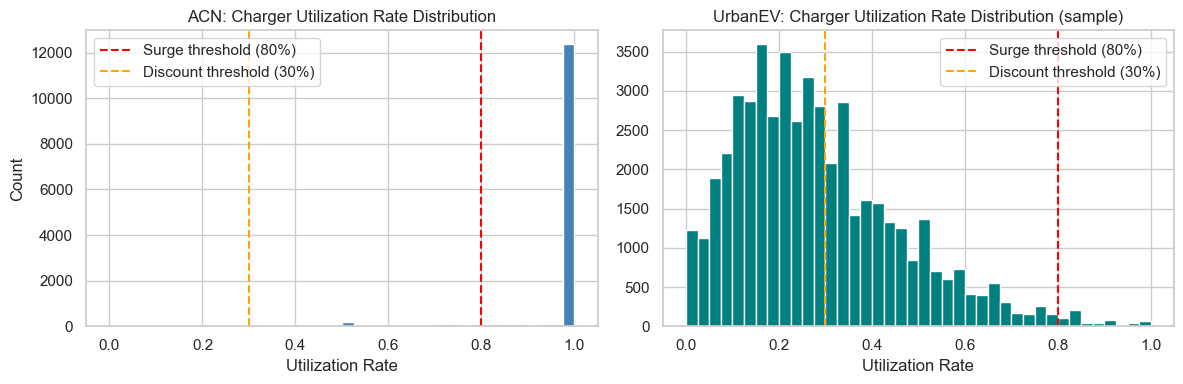

Pricing implication: both datasets show bimodal patterns — many near-zero slots and many near-full slots, confirming the case for dynamic pricing vs. a flat ₹15 tariff.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACN
axes[0].hist(acn_hourly['utilization_rate'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0.8, color='red', linestyle='--', label='Surge threshold (80%)')
axes[0].axvline(0.3, color='orange', linestyle='--', label='Discount threshold (30%)')
axes[0].set_title('ACN: Charger Utilization Rate Distribution')
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Count')
axes[0].legend()

# UrbanEV
sample_uev = uev[uev['utilization_rate'].notna()]['utilization_rate'].sample(50000, random_state=42)
axes[1].hist(sample_uev, bins=40, color='teal', edgecolor='white')
axes[1].axvline(0.8, color='red', linestyle='--', label='Surge threshold (80%)')
axes[1].axvline(0.3, color='orange', linestyle='--', label='Discount threshold (30%)')
axes[1].set_title('UrbanEV: Charger Utilization Rate Distribution (sample)')
axes[1].set_xlabel('Utilization Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_FIG / 'utilization_distributions.png', dpi=150)
plt.show()
print('Pricing implication: both datasets show bimodal patterns — many near-zero slots and many near-full slots, confirming the case for dynamic pricing vs. a flat ₹15 tariff.')

## 5. Cache Processed Data

In [10]:
# ACN session-level
acn_save = acn.copy()
for col in ['connectionTime','disconnectTime','doneChargingTime','ui_requestedDeparture']:
    if col in acn_save.columns:
        acn_save[col] = acn_save[col].astype(str)
acn_save['period'] = acn_save['period'].astype(str)
acn_save.to_parquet(OUT_DATA / 'acn_sessions_featured.parquet', index=False)

# ACN station-hour
acn_h_save = acn_hourly.copy()
acn_h_save['slot'] = acn_h_save['slot'].astype(str)
acn_h_save['period'] = acn_h_save.get('period', pd.Series([''] * len(acn_h_save))).astype(str)
acn_h_save.to_parquet(OUT_DATA / 'acn_station_hour.parquet', index=False)

# UrbanEV
uev_save = uev.copy()
uev_save['period'] = uev_save['period'].astype(str)
uev_save.to_parquet(OUT_DATA / 'urbanev_featured.parquet', index=False)

print('Saved:')
for f in ['acn_sessions_featured.parquet','acn_station_hour.parquet','urbanev_featured.parquet']:
    sz = (OUT_DATA/f).stat().st_size / 1e6
    print(f'  {f}: {sz:.1f} MB')

Saved:
  acn_sessions_featured.parquet: 1.3 MB
  acn_station_hour.parquet: 0.4 MB
  urbanev_featured.parquet: 52.2 MB
